# Model Registry & Selection

This notebook orchestrates the full pipeline:
1. Create dataset versions
2. Train & register models
3. View summary table
4. Visualise accuracy vs train / inference time
5. Visualise lineage
6. Select best models under constraints

## 1 — Create dataset versions

In [1]:
from scripts.create_datasets import make_datasets
make_datasets()


All dataset versions already exist. Skipping creation.


## 2 — Train & register models

In [2]:
from scripts.train_models import train_models
train_models()

Model model_001 already exists. Skipping.
Model model_002 already exists. Skipping.
Model model_003 already exists. Skipping.
Model model_004 already exists. Skipping.
Model model_005 already exists. Skipping.
Model model_006 already exists. Skipping.
Model model_007 already exists. Skipping.
Model model_008 already exists. Skipping.
Model model_009 already exists. Skipping.
Model model_010 already exists. Skipping.
Model model_011 already exists. Skipping.
Model model_012 already exists. Skipping.
Model model_013 already exists. Skipping.

All models trained and registered.


## 3 — Summary table

In [3]:
from scripts.summarize import load_registry
df = load_registry()
df.drop(columns=["model_config", "metrics"], errors="ignore")

,model_id,algorithm,dataset_version,accuracy,train_time_sec,inference_time_sec,parent_model_id
7,model_008,GradientBoostingClassifier,ds_v2,0.8397,0.1855,0.000596,NaN
5,model_006,GradientBoostingClassifier,ds_v1,0.8359,0.1618,0.000496,model_005
0,model_001,LogisticRegression,ds_v1,0.8244,0.0075,0.000188,NaN
3,model_004,RandomForestClassifier,ds_v1,0.8244,0.1058,0.004827,model_003
11,model_012,RandomForestClassifier,ds_v3,0.8142,0.1051,0.005075,model_004
4,model_005,GradientBoostingClassifier,ds_v1,0.8130,0.0472,0.000299,NaN
12,model_013,GradientBoostingClassifier,ds_v3,0.8117,0.4632,0.000744,model_004
10,model_011,LogisticRegression,ds_v3,0.7939,0.0023,0.000192,NaN
2,model_003,RandomForestClassifier,ds_v1,0.7901,0.0592,0.002622,NaN
1,model_002,DecisionTreeClassifier,ds_v1,0.7824,0.0017,0.000187,NaN


## 4 — Accuracy vs Train / Inference Time

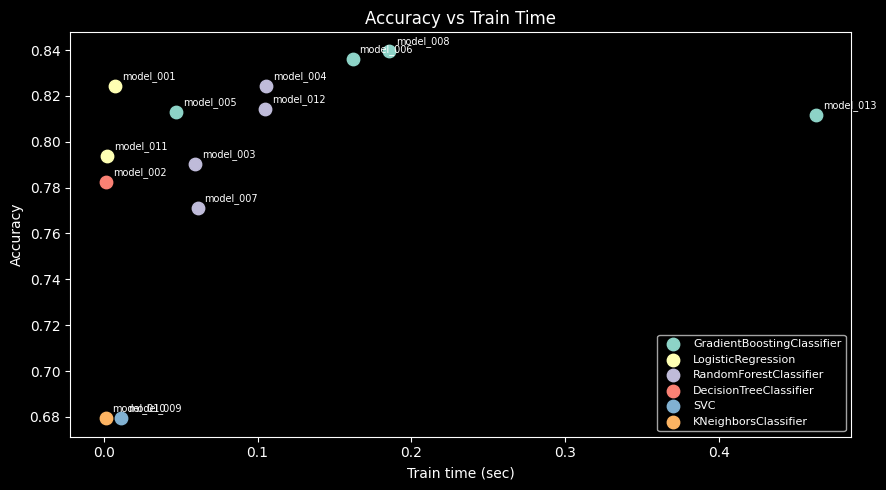

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
for algo in df["algorithm"].unique():
    sub = df[df["algorithm"] == algo]
    ax.scatter(sub["train_time_sec"], sub["accuracy"], label=algo, s=80)
    for _, r in sub.iterrows():
        ax.annotate(r["model_id"], (r["train_time_sec"], r["accuracy"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=7)

ax.set_xlabel("Train time (sec)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Train Time")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

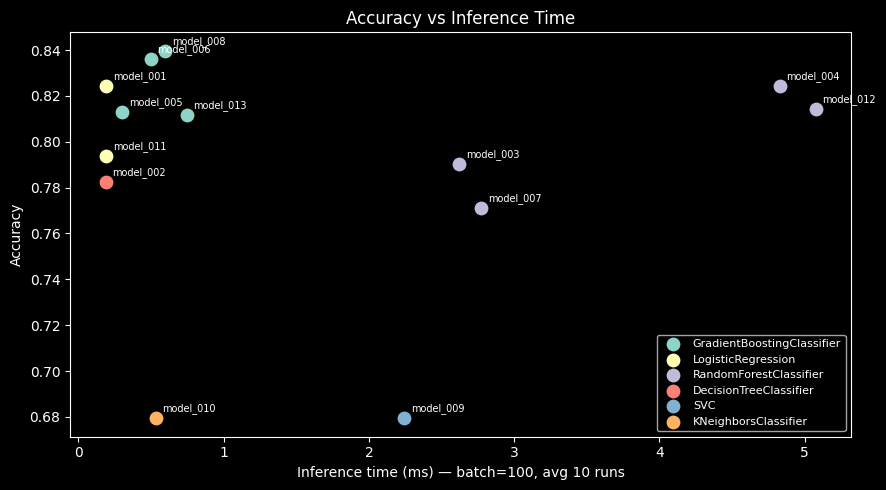

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for algo in df["algorithm"].unique():
    sub = df[df["algorithm"] == algo]
    ax.scatter(sub["inference_time_sec"] * 1000, sub["accuracy"], label=algo, s=80)
    for _, r in sub.iterrows():
        ax.annotate(r["model_id"], (r["inference_time_sec"] * 1000, r["accuracy"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=7)

ax.set_xlabel("Inference time (ms) — batch=100, avg 10 runs")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Inference Time")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5 — Model Lineage Graph

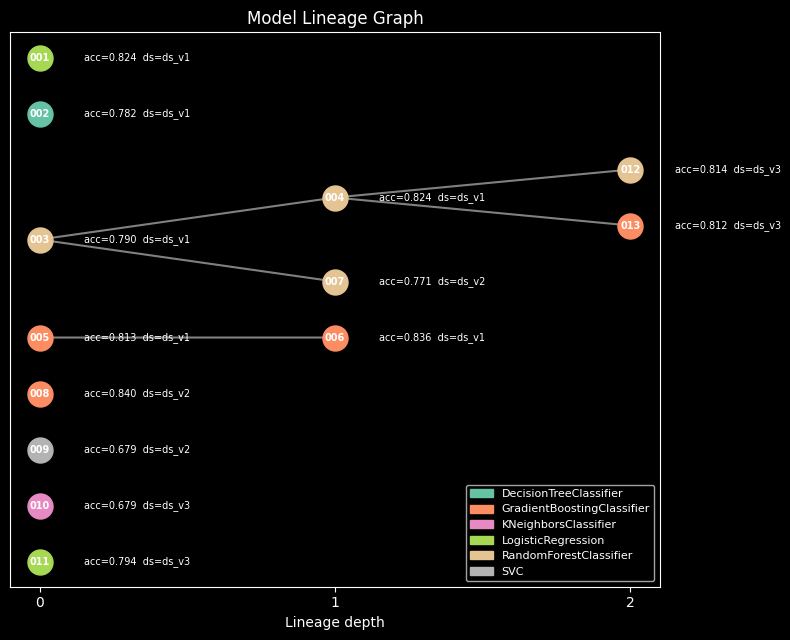

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
entries = {}
for row in df.itertuples():
    entries[row.model_id] = row._asdict()

# Build tree
children_of = {}
roots = []
for mid, entry in entries.items():
    pid = entry.get("parent_model_id")
    if pid and pid in entries:
        children_of.setdefault(pid, []).append(mid)
    elif not pid or math.isnan(pid):
        roots.append(mid)

# Assign positions: roots get column 0, their children column 1, etc.
positions = {}
y_counter = [0]  # mutable counter

def layout(mid, depth=0):
    kids = sorted(children_of.get(mid, []))
    if not kids:
        positions[mid] = (depth, y_counter[0])
        y_counter[0] += 1
    else:
        for cid in kids:
            layout(cid, depth + 1)
        child_ys = [positions[c][1] for c in kids]
        positions[mid] = (depth, sum(child_ys) / len(child_ys))

for root in sorted(roots):
    layout(root)

# Also place orphan models (parent not in registry)
for mid in entries:
    if mid not in positions:
        positions[mid] = (0, y_counter[0])
        y_counter[0] += 1

# Color map by algorithm
algos = sorted(set(e["model_config"]["algorithm"] for e in entries.values()))
cmap = plt.cm.Set2
algo_color = {a: cmap(i / max(len(algos) - 1, 1)) for i, a in enumerate(algos)}

fig, ax = plt.subplots(figsize=(8, len(entries) * 0.5))

# Draw edges
for mid, e in entries.items():
    pid = e.get("parent_model_id")
    if pid and pid in positions and mid in positions:
        px, py = positions[pid]
        cx, cy = positions[mid]
        ax.annotate("", xy=(cx, cy), xytext=(px, py),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))

# Draw nodes
for mid, (x, y) in positions.items():
    e = entries[mid]
    color = algo_color[e["model_config"]["algorithm"]]
    ax.plot(x, y, "o", markersize=18, color=color, zorder=3)
    ax.text(x, y, mid.replace("model_", ""), ha="center", va="center", fontsize=7, fontweight="bold", zorder=4)
    label = f"acc={e['metrics']['accuracy']:.3f}  ds={e['dataset_version']}"
    ax.text(x + 0.15, y, label, va="center", fontsize=7, zorder=4)

# Legend
handles = [mpatches.Patch(color=algo_color[a], label=a) for a in algos]
ax.legend(handles=handles, fontsize=8, loc="lower right")

ax.set_xlabel("Lineage depth")
ax.set_title("Model Lineage Graph")
ax.set_xticks(range(max(x for x, _ in positions.values()) + 1))
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6 — Model Selection (budget constraint)

In [7]:
from scripts.select_model import select_model

select_model(df, max_train_time_sec=0.2, min_accuracy=0.8)

Budget: train_time <= 0.2s | accuracy >= 0.800 | inference_time <= infms
Eligible models: 6 / 13

Best model: model_008
  Algorithm      : GradientBoostingClassifier
  Accuracy       : 0.8397
  Train time     : 0.1855s
  Inference time : 0.596ms  (batch=100)


,model_id,algorithm,dataset_version,accuracy,train_time_sec,inference_time_sec,model_config,metrics,parent_model_id
7,model_008,GradientBoostingClassifier,ds_v2,0.8397,0.1855,0.000596,"{'algorithm': 'GradientBoostingClassifier', 'h...","{'accuracy': 0.8397, 'f1': 0.7789, 'precision'...",NaN
5,model_006,GradientBoostingClassifier,ds_v1,0.8359,0.1618,0.000496,"{'algorithm': 'GradientBoostingClassifier', 'h...","{'accuracy': 0.8359, 'f1': 0.7772, 'precision'...",model_005
0,model_001,LogisticRegression,ds_v1,0.8244,0.0075,0.000188,"{'algorithm': 'LogisticRegression', 'hyperpara...","{'accuracy': 0.8244, 'f1': 0.7604, 'precision'...",NaN
3,model_004,RandomForestClassifier,ds_v1,0.8244,0.1058,0.004827,"{'algorithm': 'RandomForestClassifier', 'hyper...","{'accuracy': 0.8244, 'f1': 0.7629, 'precision'...",model_003
11,model_012,RandomForestClassifier,ds_v3,0.8142,0.1051,0.005075,"{'algorithm': 'RandomForestClassifier', 'hyper...","{'accuracy': 0.8142, 'f1': 0.7542, 'precision'...",model_004
4,model_005,GradientBoostingClassifier,ds_v1,0.8130,0.0472,0.000299,"{'algorithm': 'GradientBoostingClassifier', 'h...","{'accuracy': 0.813, 'f1': 0.738, 'precision': ...",NaN


In [8]:
select_model(df, max_train_time_sec=0.2, min_accuracy=0.8, max_inference_time_sec=0.001)

Budget: train_time <= 0.2s | accuracy >= 0.800 | inference_time <= 1.0ms
Eligible models: 4 / 13

Best model: model_008
  Algorithm      : GradientBoostingClassifier
  Accuracy       : 0.8397
  Train time     : 0.1855s
  Inference time : 0.596ms  (batch=100)


,model_id,algorithm,dataset_version,accuracy,train_time_sec,inference_time_sec,model_config,metrics,parent_model_id
7,model_008,GradientBoostingClassifier,ds_v2,0.8397,0.1855,0.000596,"{'algorithm': 'GradientBoostingClassifier', 'h...","{'accuracy': 0.8397, 'f1': 0.7789, 'precision'...",NaN
5,model_006,GradientBoostingClassifier,ds_v1,0.8359,0.1618,0.000496,"{'algorithm': 'GradientBoostingClassifier', 'h...","{'accuracy': 0.8359, 'f1': 0.7772, 'precision'...",model_005
0,model_001,LogisticRegression,ds_v1,0.8244,0.0075,0.000188,"{'algorithm': 'LogisticRegression', 'hyperpara...","{'accuracy': 0.8244, 'f1': 0.7604, 'precision'...",NaN
4,model_005,GradientBoostingClassifier,ds_v1,0.8130,0.0472,0.000299,"{'algorithm': 'GradientBoostingClassifier', 'h...","{'accuracy': 0.813, 'f1': 0.738, 'precision': ...",NaN
